###Autoencoder for Image Denoising using the MNIST Dataset










Step 1: Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

Successfully imported all the required libraries for data loading, preprocessing, visualization, and building the autoencoder model.


Step 2: Load the MNIST Dataset


In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images Shape :", x_train.shape)
print("Testing Images Shape  :", x_test.shape)
print("Image Size            :", x_train[0].shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images Shape : (60000, 28, 28)
Testing Images Shape  : (10000, 28, 28)
Image Size            : (28, 28)


Observation:

The MNIST dataset was successfully loaded. It contains 60,000 training images and 10,000 testing images. Each image is a grayscale handwritten digit with a resolution of 28 × 28 pixels.

Step 3: Normalize the Images

In [3]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum Pixel Value :", x_train.min())
print("Maximum Pixel Value :", x_train.max())

Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


Observation:

The images were successfully normalized by scaling the pixel values from the range 0–255 to 0–1. This preprocessing step helps the autoencoder train faster and improves model performance.

Step 4: Flatten the Images

In [4]:
x_train = x_train.reshape((x_train.shape[0], 784))
x_test = x_test.reshape((x_test.shape[0], 784))

print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

Training Data Shape : (60000, 784)
Testing Data Shape  : (10000, 784)


Observation:

The 28 × 28 images were successfully reshaped into one-dimensional vectors containing 784 pixels. This transformation is necessary because the autoencoder uses fully connected (Dense) layers, which require one-dimensional input.

Step 5: Add Noise to the Images

In [5]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy Training Data Shape :", x_train_noisy.shape)
print("Noisy Testing Data Shape  :", x_test_noisy.shape)

Noisy Training Data Shape : (60000, 784)
Noisy Testing Data Shape  : (10000, 784)


Observation:

Random Gaussian noise was successfully added to the training and testing images while maintaining the original dimensions. The pixel values were clipped to the range 0–1 to ensure valid image data for training the autoencoder.

Step 6: Visualize Original and Noisy Images

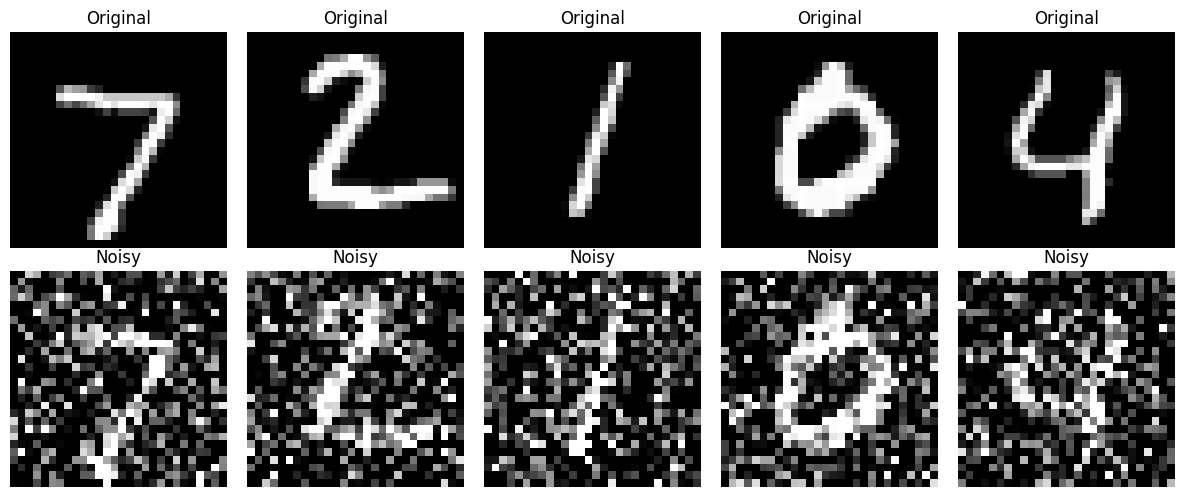

In [6]:
n = 5

plt.figure(figsize=(12, 5))


for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

for i in range(n):
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

Observation:

The visualization shows the original handwritten digit images and their corresponding noisy versions. Gaussian noise has been successfully added while preserving the overall digit structure, allowing the autoencoder to learn how to reconstruct clean images from noisy inputs.

Step 7: Build the Autoencoder Model

In [7]:
input_img = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)


autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Observation:

The autoencoder model was successfully created using Dense layers. The encoder compresses the input image into a lower-dimensional representation, while the decoder reconstructs the original image from the compressed features. The model contains 222,384 trainable parameters.

Step 8: Compile the Autoencoder Model

In [8]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

print("Model compiled successfully.")

Model compiled successfully.


Observation:

The autoencoder model was successfully compiled using the Adam optimizer and Binary Crossentropy loss function. The model is now ready to learn how to reconstruct clean images from noisy inputs during training.

Step 9: Train the Autoencoder Model

In [9]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.2628 - val_loss: 0.2026
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1869 - val_loss: 0.1728
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1672 - val_loss: 0.1596
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1570 - val_loss: 0.1528
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1512 - val_loss: 0.1479
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1460 - val_loss: 0.1427
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1418 - val_loss: 0.1396
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1391 - val_loss: 0.1374
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1369 - val_loss: 0.1356
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1347 - val_loss: 0.1342
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1329 - val_loss: 0.1325
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

Observation:

The autoencoder model was successfully trained for 20 epochs. Both the training loss and validation loss decreased consistently throughout the training process, indicating that the model effectively learned to reconstruct clean images from noisy inputs.

Step 10: Plot the Training and Validation Loss

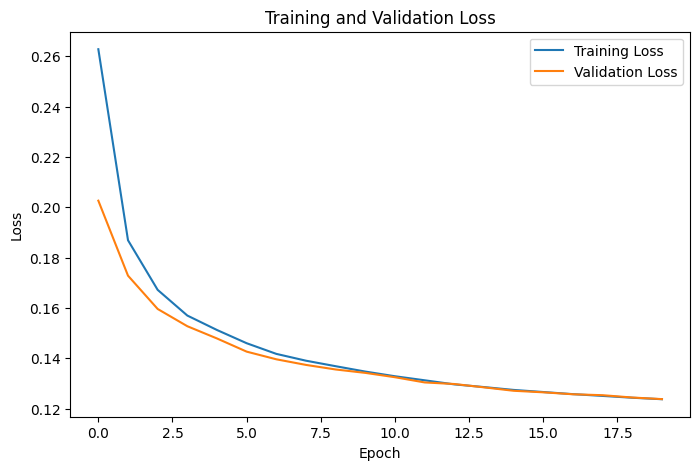

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Observation:

The training and validation loss decreased steadily with each epoch and converged to nearly the same value. This indicates that the autoencoder learned effectively and generalized well to unseen noisy images without significant overfitting.

Step 11: Reconstruct (Denoise) the Images

In [11]:
decoded_images = autoencoder.predict(x_test_noisy)

print("Reconstructed Images Shape :", decoded_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Reconstructed Images Shape : (10000, 784)


Observation:

The trained autoencoder successfully reconstructed the noisy test images. The reconstructed output has the same dimensions as the original images, confirming that the model can generate denoised images from noisy inputs.

Step 12: Compare Original, Noisy, and Denoised Images

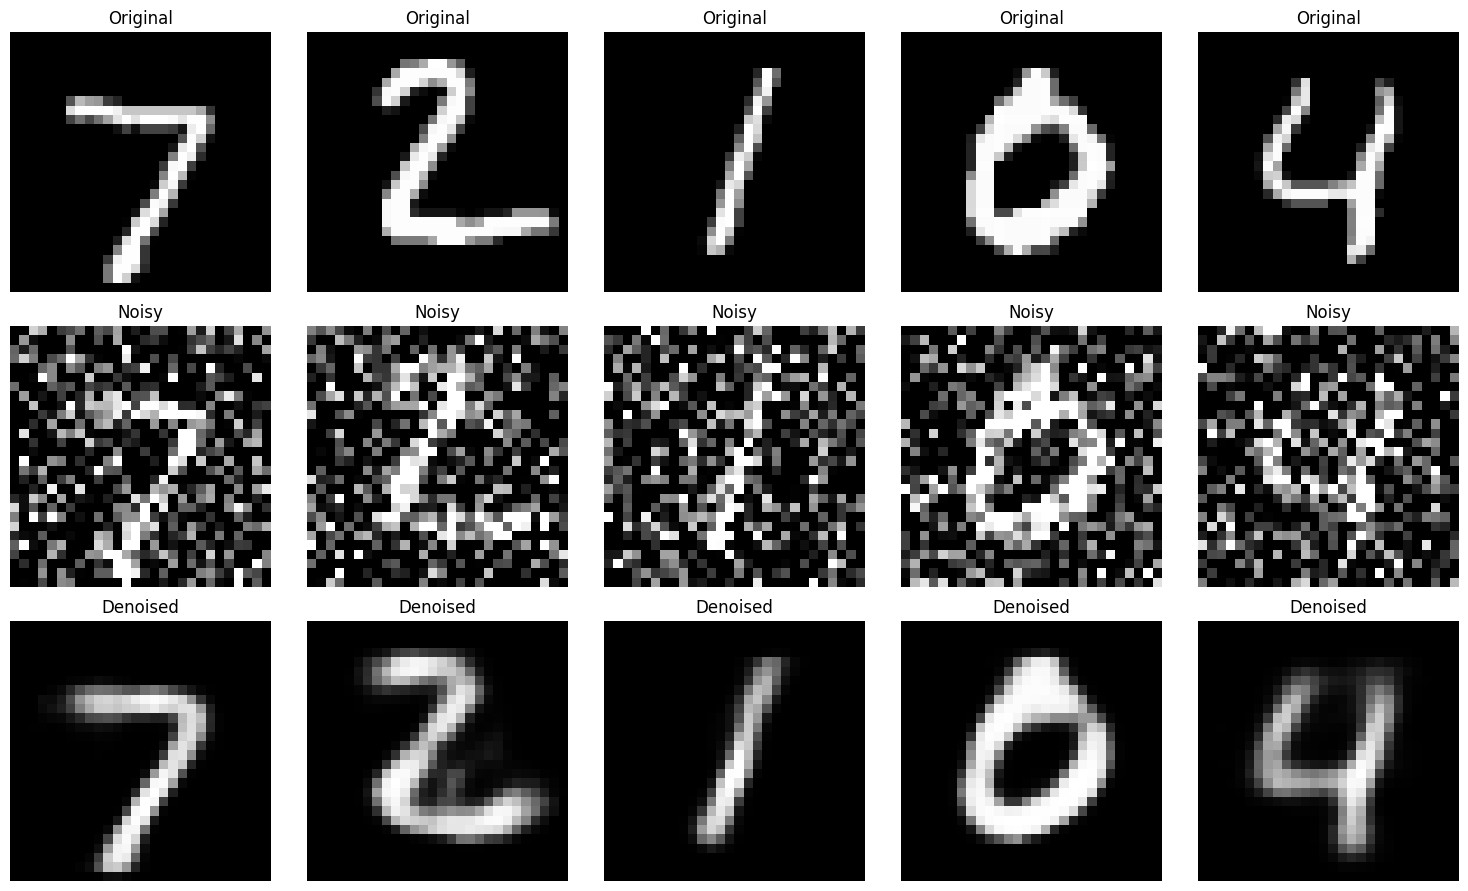

In [12]:
n = 5

plt.figure(figsize=(15, 9))

for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

Observation:

The reconstructed images contain significantly less noise than the noisy input images while preserving the original digit structure. Although the reconstructed images appear slightly blurred, the autoencoder successfully learned to remove noise and recover the essential features of the handwritten digits.

###Conclusion


In this project, an Autoencoder was developed to remove noise from handwritten digit images using the MNIST dataset. Gaussian noise was added to the original images, and the model was trained to reconstruct clean images from noisy inputs. The training and validation losses decreased consistently, indicating effective learning. The reconstructed images showed a significant reduction in noise while preserving the important features of the digits, demonstrating the effectiveness of autoencoders for image denoising.